<center>

# **Primera pueba de MLP**

</center>


---

**Autor**: Isaac Yael Cantú Fernández

**Fecha**: 10/04/2026

## **1. Análisis exploratorio de datos**
---

> **Librerías**

In [186]:
df1 = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df2 = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/DAT_corsikaio_5000.txt")

(df1["particle_description"].values == df2["particle_description"].values).all()


np.True_

In [187]:

n_fila = 0
for i in df2['particle_description']:
    n_fila += 1
    if int(i) != df1["particle_description"][n_fila-1]:
        print(n_fila)
        break


In [188]:
df3 = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")

for i in range(1,5001):
    if i not in df3["event_no"]:
        print(i)

5000


In [189]:
# Se importan librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Red Neuronal
from sklearn.model_selection import train_test_split

> **Importación de base de datos**

En esta sección se exportan la base de datos correspondiente a las partículas de la simulación y los datos de cada shower, los datos se encuentran con la siguiente información:

- **Partículas**:
    - `shower`: Número de shower basado en el EVTNR
    - `particle_type`: Tipo de partícula 
    - `no_particle`: Número de la partícula (identificador) (1 a 195)
    - `hadr_gen`: generación hadrónica
    - `no_obs`: Número de nivel de observación
    - `mass`: Masa de la partícula en GeV
    - `energy`: Energía relativista de la partícula en GeV
    - `particle_description`: Identificador de la partícula en formato: part. id×1000 + hadr. generation × 10 + no. of obs. level
    - `px`: momento de la partícula en dirección x en GeV/C
    - `py`: momento de la partícula en dirección y en GeV/C
    - `pz`: momento de la partícula en dirección -z en GeV/C
    - `x`: coordenada de la posición en x en cm
    - `y`: coordenada de la posición en y en cm
    - `t`: tiempo desde la primera interacción en nsec

- **Shower**:
    - `event_no`: Número de shower basado en el EVTNR
    - `particle_id`: Id de partícula (particle code or A × 100 + Z for nuclei)
    - `total_energy`: Energía relativista de la partícula en GeV
    - `altitude`: Altura de inicio en g/cm2
    - `no_target`: Number of first target if fixed
    - `z`: z coordinate (height) of first interaction in cm
    - `px`: momento en dirección x en GeV/C
    - `py`: momento en dirección y en GeV/C
    - `pz`: momento de la partícula en dirección -z en GeV/C
    - `zenith`: zenith angle θ in radian
    - `azimuth`: azimuth angle φ in radian



In [190]:
df_particles= pd.read_csv("/home/icantu24/Documents/corsario/dat_files/corsario_5000.csv")
df_shower = pd.read_csv("/home/icantu24/Documents/corsario/dat_files/shower_corsario_5000.csv")

> **Visualizacion de base de datos de las partículas**

In [191]:
df_particles.head()

,shower,particle_type,no_particle,hadr_gen,no_obs,mass,energy,particle_description,px,py,pz,x,y,t
0,1,μ−,6,52,1,0.105658,12.732127,6521,-5.336977,-6.832778,9.323396,-152691.328125,122567.742188,155795.562500
1,1,μ−,6,53,1,0.105658,1.542738,6531,-0.529347,-0.588978,1.319763,163733.828125,425957.218750,147149.296875
2,1,μ−,6,53,1,0.105658,5.683524,6531,-2.054344,-3.307787,4.138780,27992.837891,-19151.738281,156171.250000
3,1,γ,1,99,1,0.000000,0.026479,1991,-0.009340,-0.018759,0.016186,-79088.984375,-12423.223633,157801.671875
4,1,γ,1,99,1,0.000000,0.002923,1991,-0.001302,-0.001356,0.002238,-70280.101562,6012.798828,157295.843750


> **Visualización de la base de datos de shower**

In [192]:
df_shower.head()

,event_no,particle_id,total_energy,altitude,no_target,z,px,py,pz,zenith,azimuth
0,1.0,14.0,294.369263,0.0,0.0,3782808.250,-109.950226,-171.157135,212.764114,0.762975,-2.141806
1,2.0,14.0,101.485573,0.0,0.0,2797595.250,-0.135202,58.291382,83.069481,0.611880,1.573116
2,3.0,14.0,191.815186,0.0,0.0,2221731.250,-122.569984,-81.189651,123.195061,0.873344,-2.556554
3,4.0,14.0,117.957367,0.0,0.0,2275635.250,94.996376,0.325815,69.918823,0.936308,0.003430
4,5.0,14.0,400.035583,0.0,0.0,1952248.125,300.654297,-67.543701,255.092987,0.879317,-0.220987


### **1.1 Análisis datos**

> **Cantidad de datos de partículas**

In [193]:
df_particles["shower"].value_counts()

shower
3939    51301
3920    50028
1212    15400
2027    15333
2882    13077
        ...  
4710        1
4721        1
4878        1
4934        1
4983        1
Name: count, Length: 4977, dtype: int64

In [194]:
df_particles["particle_type"].value_counts()

particle_type
γ     663056
e−     54339
e+     30698
μ+     18655
μ−     17315
n       7343
p       2062
π+       106
π-        93
K◦         2
K-         1
Name: count, dtype: int64

In [195]:
for i in range(1,1001):
    if i not in set(df_particles["shower"]):
        print(i)

185
331
971


In [196]:
for i in range(1,1001):
    if i not in set(df_shower["event_no"]):
        print(i)

> **Verificación de NaN o emptys**

In [197]:
for col in df_particles.columns:
    print(f"{col}: {df_particles[col].isna().any()}")

shower: False
particle_type: True
no_particle: False
hadr_gen: False
no_obs: False
mass: False
energy: False
particle_description: False
px: False
py: False
pz: False
x: False
y: False
t: False


In [198]:
for col in df_particles.columns:
    idx = df_particles[df_particles[col].isna()].index
    if len(idx) > 0:
        print(f"{col} tiene NaN en filas: {list(idx)}")

particle_type tiene NaN en filas: [26574, 34107, 39399, 74082, 89725, 91156, 155056, 171221, 179430, 215531, 233188, 237409, 245115, 263344, 276434, 288983, 314843, 314962, 337954, 341376, 372311, 423753, 470595, 525741, 529958, 629681, 629745, 668196, 766096, 769316]


In [199]:
df_shower.isna().any().any()

np.False_

> **Total de datos**

In [200]:
print(len(df_particles["shower"]))
print(len(df_shower["event_no"]))

793700
5000


### **1.2 Gráficas de datos** 

#### **A. Gráficas de partículas** 

> **Histograma: número de partículas por shower**

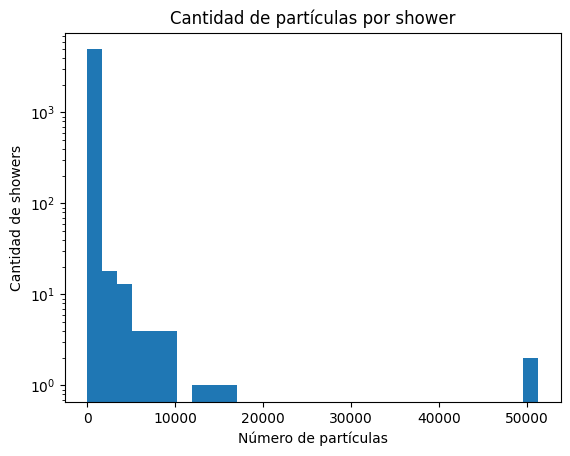

In [201]:
particles_per_shower = df_particles.groupby("shower").size()

plt.figure()
plt.hist(particles_per_shower, bins=30)
plt.xlabel("Número de partículas")
plt.ylabel("Cantidad de showers")
plt.title("Cantidad de partículas por shower")
plt.yscale("log")
plt.show()

> **Histograma de energía de partículas**

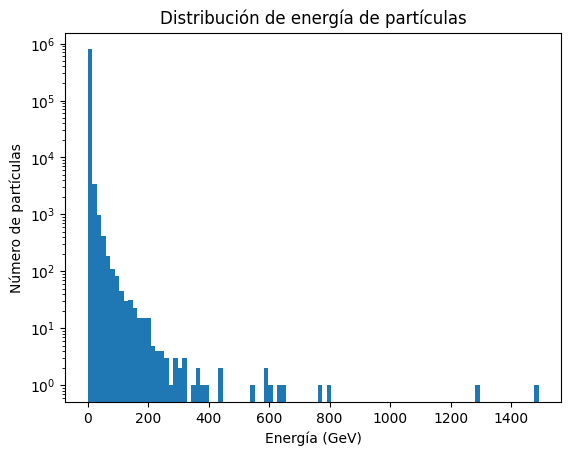

In [202]:
plt.figure()
plt.hist(df_particles["energy"], bins=100)
plt.xlabel("Energía (GeV)")
plt.ylabel("Número de partículas")
plt.title("Distribución de energía de partículas")
plt.yscale("log")
plt.show()

> **Boxplot de energía por shower**

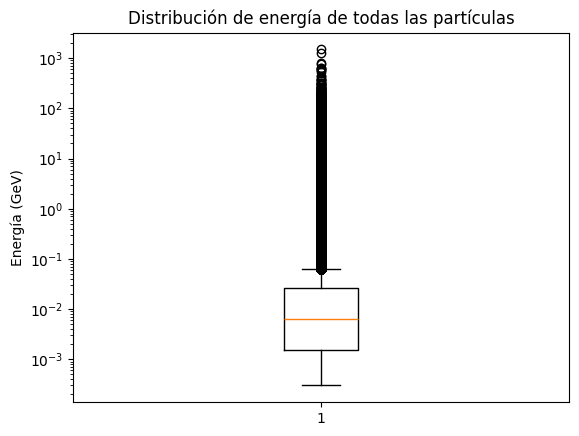

In [203]:
plt.figure()

plt.boxplot(df_particles["energy"], vert=True)

plt.ylabel("Energía (GeV)")
plt.title("Distribución de energía de todas las partículas")
plt.yscale("log")
plt.show()

> **Posiciones x-y coloreadas por tipo de partícula**

847.0    8671
860.0    3621
989.0    3412
661.0    2994
465.0    2506

464    0.784273
Name: azimuth, dtype: float64
464    0.818435
Name: zenith, dtype: float64


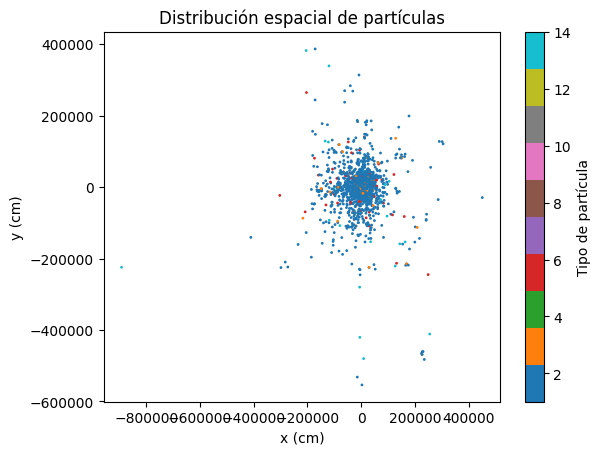

In [204]:
plt.figure()

number_event = 465


dispersion = df_particles[df_particles["shower"]==number_event]

dispersion_shower = df_shower[df_shower["event_no"]==number_event]

print(dispersion_shower["azimuth"]*2*np.pi)
print(dispersion_shower["zenith"]*2*np.pi)

scatter = plt.scatter(
    dispersion["x"],
    dispersion["y"],
    c=dispersion["no_particle"],
    s=1,
    cmap="tab10"
)

plt.xlabel("x (cm)")
plt.ylabel("y (cm)")

plt.title("Distribución espacial de partículas")

cbar = plt.colorbar(scatter)
cbar.set_label("Tipo de partícula")

plt.show()

> **Histogramas de momentos**

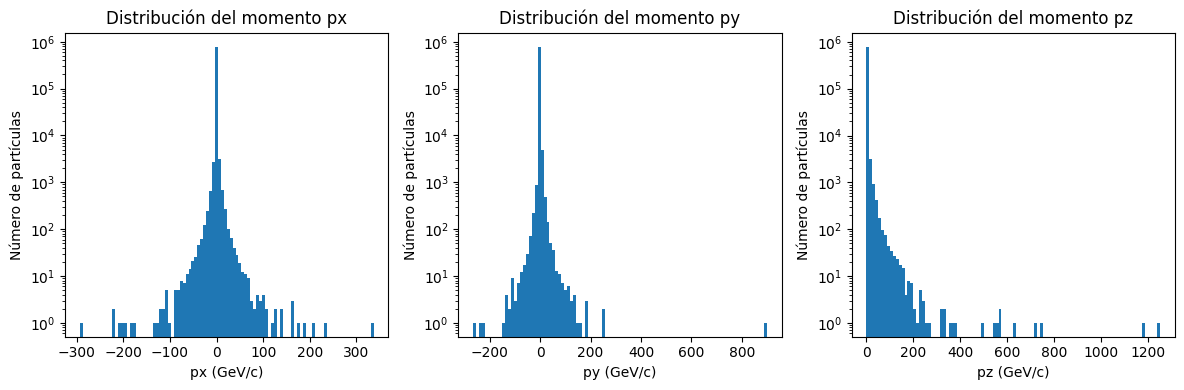

In [205]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))


ax[0].hist(df_particles["px"], bins=100)
ax[0].set_xlabel("px (GeV/c)")
ax[0].set_ylabel("Número de partículas")
ax[0].set_title("Distribución del momento px")
ax[0].set_yscale("log")

ax[1].hist(df_particles["py"], bins=100)
ax[1].set_xlabel("py (GeV/c)")
ax[1].set_ylabel("Número de partículas")
ax[1].set_title("Distribución del momento py")
ax[1].set_yscale("log")

ax[2].hist(df_particles["pz"], bins=100)
ax[2].set_xlabel("pz (GeV/c)")
ax[2].set_ylabel("Número de partículas")
ax[2].set_title("Distribución del momento pz")
ax[2].set_yscale("log")

plt.tight_layout()
plt.show()

#### **B. Gráficas para Showers**

> **Número de evento vs energía**

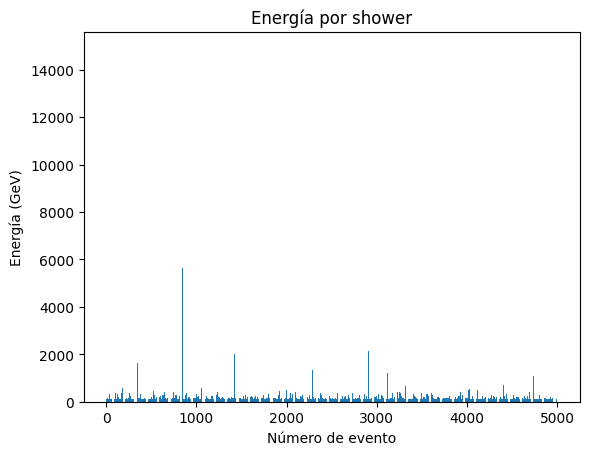

In [206]:
plt.figure()

plt.bar(
    df_shower["event_no"],
    df_shower["total_energy"]
)

plt.xlabel("Número de evento")
plt.ylabel("Energía (GeV)")
#plt.yscale("log")
plt.title("Energía por shower")

plt.show()

> **Histograma de energía de showers**

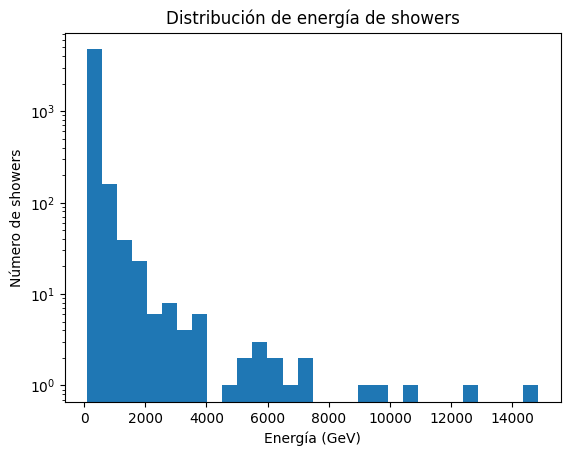

In [207]:
plt.figure()

plt.hist(df_shower["total_energy"], bins=30)

plt.xlabel("Energía (GeV)")
plt.ylabel("Número de showers")
plt.yscale("log")
plt.title("Distribución de energía de showers")

plt.show()

> **Boxplot de energía de showers**

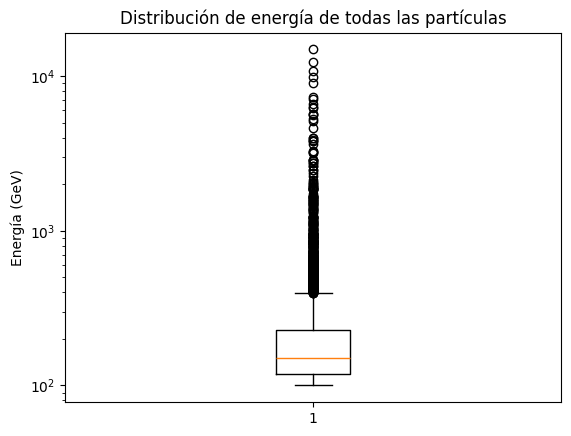

In [208]:
plt.figure()

plt.boxplot(df_shower["total_energy"], vert=True)

plt.ylabel("Energía (GeV)")
plt.yscale("log")
plt.title("Distribución de energía de todas las partículas")

plt.show()

> **Histogramas de ángulos**

In [209]:
df_shower

,event_no,particle_id,total_energy,altitude,no_target,z,px,py,pz,zenith,azimuth
0,1.0,14.0,294.369263,0.0,0.0,3782808.250,-109.950226,-171.157135,212.764114,0.762975,-2.141806
1,2.0,14.0,101.485573,0.0,0.0,2797595.250,-0.135202,58.291382,83.069481,0.611880,1.573116
2,3.0,14.0,191.815186,0.0,0.0,2221731.250,-122.569984,-81.189651,123.195061,0.873344,-2.556554
3,4.0,14.0,117.957367,0.0,0.0,2275635.250,94.996376,0.325815,69.918823,0.936308,0.003430
4,5.0,14.0,400.035583,0.0,0.0,1952248.125,300.654297,-67.543701,255.092987,0.879317,-0.220987
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996.0,14.0,111.581505,0.0,0.0,2236272.750,0.049296,41.627319,103.521576,0.382326,1.569612
4996,4997.0,14.0,113.045883,0.0,0.0,2105713.500,15.974498,-38.617603,105.033264,0.378682,-1.178571
4997,4998.0,14.0,105.404510,0.0,0.0,1874965.375,13.186173,-84.527771,61.566315,0.947002,-1.416045
4998,4999.0,14.0,246.287338,0.0,0.0,1735253.500,-70.230591,-68.733017,225.831818,0.410425,-2.366971


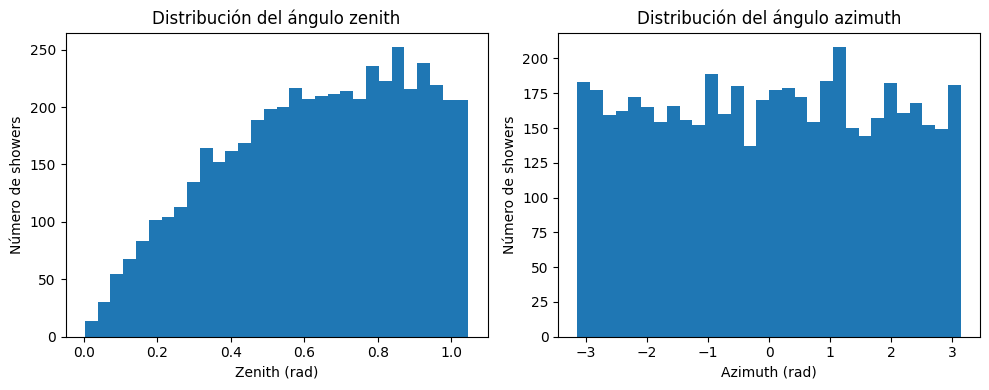

In [210]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Zenith
ax[0].hist(df_shower["zenith"], bins=30)
ax[0].set_xlabel("Zenith (rad)")
ax[0].set_ylabel("Número de showers")
ax[0].set_title("Distribución del ángulo zenith")

# Azimuth
ax[1].hist(df_shower["azimuth"], bins=30)
ax[1].set_xlabel("Azimuth (rad)")
ax[1].set_ylabel("Número de showers")
ax[1].set_title("Distribución del ángulo azimuth")

plt.tight_layout()
plt.show()